# Estimating Causal Effects of Genetic Perturbations in Perturb-seq

This notebook implements the analysis described in the project proposal:

- Estimate the **average treatment effect (ATE)** of a selected genetic perturbation on a low-dimensional outcome (a pathway score, e.g. UPR).
- Compare a **naive** treated-vs-control mean difference with a **state-adjusted matching** estimator that conditions on cell-state covariates $Z_i$.
- Report **balance / overlap diagnostics**, **robustness checks**, and an **optional heterogeneous-effects** analysis.

Notation (matching the proposal):

- $T_i \in \{0, 1\}$ — perturbation indicator for cell $i$
- $Y_i$ — outcome (pathway score for cell $i$)
- $Z_i$ — observed cell-state covariates
- $\tau = \mathbb{E}[Y_i(1) - Y_i(0)]$ — ATE
- $\tau(z) = \mathbb{E}[Y_i(1) - Y_i(0) \mid Z_i = z]$ — CATE

The notebook runs on the real `mixscape_hvg_filter.h5ad` dataset.


## 1. Setup


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, Sequence

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

import anndata as ad

try:
    import scanpy as sc
    HAS_SCANPY = True
except ImportError:
    HAS_SCANPY = False

sns.set_theme(style='whitegrid')
RNG = np.random.default_rng(0)

print('anndata:', ad.__version__)
print('scanpy available:', HAS_SCANPY)


anndata: 0.12.16
scanpy available: False


## 2. Configuration

All knobs that change the analysis live here.  `data_paths` lists the candidate locations of the `.h5ad`; the loader uses the first one that exists.


In [2]:
@dataclass
class Config:
    # Candidate paths to look for the h5ad in.  The first one that exists wins.
    data_paths: Sequence[Path] = field(default_factory=lambda: [
        Path('/content/drive/MyDrive/MyProjectData/mixscape_hvg_filter.h5ad'),
        Path.home() / 'Downloads' / 'mixscape_hvg_filter.h5ad',
        Path.home() / 'perturb_data' / 'mixscape_hvg_filter.h5ad',
        Path('mixscape_hvg_filter.h5ad'),
    ])

    # Column in adata.obs that holds the perturbation target gene.
    pert_col: str = 'gene'
    # Value (or values) in pert_col that should be treated as control.
    # In the real UPR Perturb-seq file, control cells are labelled 'CTRL'.
    control_labels: tuple = ('CTRL', 'NT', 'non-targeting', 'control', 'NTC')

    # Perturbation gene we want to estimate the effect for.
    # AMIGO3 has a moderate, significant effect on the UPR score AND good
    # treated/control overlap (propensity AUC ~0.68), so the positivity
    # assumption is plausible and matching can actually balance covariates.
    # (Contrast: HSPA5 has a huge effect but near-zero overlap.)
    target_perturbation: Optional[str] = 'AMIGO3'

    # Outcome definition: a curated UPR gene set.  We will use whichever of
    # these are present in adata.var_names.
    upr_gene_set: tuple = (
        'HSPA5', 'DDIT3', 'ATF4', 'ATF6', 'XBP1', 'ERN1', 'EIF2AK3',
        'HSP90B1', 'HERPUD1', 'EDEM1', 'SEC24D', 'MANF', 'DNAJB9',
        'PDIA4', 'PDIA6', 'CALR', 'PDIA3', 'SEL1L', 'HYOU1', 'DNAJC3',
    )

    # Number of nearest control neighbours used by the matching estimator.
    k_neighbors: int = 10
    # Number of latent dimensions to use as Z (PCA components).
    n_pcs: int = 30
    # QC columns to also include in Z.
    qc_cols: tuple = ('total_counts', 'pct_counts_mt', 'n_genes_by_counts')

    # Bootstrap iterations for confidence intervals.
    n_bootstrap: int = 200

    # Random seed.
    seed: int = 0

CFG = Config()
CFG


Config(data_paths=[PosixPath('/content/drive/MyDrive/MyProjectData/mixscape_hvg_filter.h5ad'), PosixPath('/Users/kevin/Downloads/mixscape_hvg_filter.h5ad'), PosixPath('/Users/kevin/perturb_data/mixscape_hvg_filter.h5ad'), PosixPath('mixscape_hvg_filter.h5ad')], pert_col='gene', control_labels=('CTRL', 'NT', 'non-targeting', 'control', 'NTC'), target_perturbation='AMIGO3', upr_gene_set=('HSPA5', 'DDIT3', 'ATF4', 'ATF6', 'XBP1', 'ERN1', 'EIF2AK3', 'HSP90B1', 'HERPUD1', 'EDEM1', 'SEC24D', 'MANF', 'DNAJB9', 'PDIA4', 'PDIA6', 'CALR', 'PDIA3', 'SEL1L', 'HYOU1', 'DNAJC3'), k_neighbors=10, n_pcs=30, qc_cols=('total_counts', 'pct_counts_mt', 'n_genes_by_counts'), n_bootstrap=200, seed=0)

## 3. Load data

We load the real `mixscape_hvg_filter.h5ad`.  The loader checks the candidate paths in `CFG.data_paths` in order and uses the first one that exists.  If none is found it raises a clear error instead of silently continuing.


In [3]:
def find_data_path(cfg: Config) -> Optional[Path]:
    for p in cfg.data_paths:
        if Path(p).exists():
            return Path(p)
    return None


found = find_data_path(CFG)
if found is None:
    raise FileNotFoundError(
        'Could not find mixscape_hvg_filter.h5ad at any of the candidate paths:\n'
        + '\n'.join(f'  - {p}' for p in CFG.data_paths)
        + '\nUpdate CFG.data_paths to point to the file.'
    )

print(f'Loading real data from: {found}')
adata = ad.read_h5ad(found)

print()
print(adata)


Loading real data from: /Users/kevin/Downloads/mixscape_hvg_filter.h5ad

AnnData object with n_obs × n_vars = 43550 × 2000
    obs: 'gene', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'mixscape_class_p_ko', 'mixscape_class', 'mixscape_class_global', 'pertclass'
    var: 'ENSEMBL', 'ENTREZID', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden', 'log1p', 'mixscape', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'X_pert', 'normal_counts'
    obsp: 'connectivities', 'distances'


## 4. Define the treatment $T$: one perturbation + non-targeting controls

We restrict the analysis to a single perturbation (`CFG.target_perturbation`) and the non-targeting control cells.  All other perturbations are dropped.


In [4]:
def pick_target_perturbation(adata: ad.AnnData, cfg: Config) -> str:
    if cfg.target_perturbation is not None:
        return cfg.target_perturbation
    counts = adata.obs[cfg.pert_col].astype(str).value_counts()
    # Largest non-control category
    for label, _ in counts.items():
        if str(label) not in cfg.control_labels:
            return str(label)
    raise RuntimeError('No non-control perturbation found')


def build_treatment_subset(adata: ad.AnnData, target: str, cfg: Config) -> ad.AnnData:
    pert = adata.obs[cfg.pert_col].astype(str)
    is_target = pert == target
    is_control = pert.isin(cfg.control_labels)
    keep = is_target | is_control
    sub = adata[keep.values].copy()
    sub.obs['T'] = is_target[keep].astype(int).values

    n_treated = int(sub.obs['T'].sum())
    n_control = int((1 - sub.obs['T']).sum())
    if n_treated == 0 or n_control == 0:
        print('Top perturbation labels in the full dataset:')
        print(pert.value_counts().head(30))
        raise ValueError(
            f'Need both treated and control cells, got n_treated={n_treated}, n_control={n_control}. '
            f'Check CFG.target_perturbation={target!r} and CFG.control_labels={cfg.control_labels!r}.'
        )
    return sub


target = pick_target_perturbation(adata, CFG)
print(f'Target perturbation: {target!r}')

sub = build_treatment_subset(adata, target, CFG)
print(f'\nAfter filtering: {sub.n_obs} cells '
      f'({int(sub.obs["T"].sum())} treated, {int((1 - sub.obs["T"]).sum())} control)')
print('\nperturbation labels kept:')
print(sub.obs[CFG.pert_col].value_counts())


Target perturbation: 'AMIGO3'

After filtering: 8287 cells (741 treated, 7546 control)

perturbation labels kept:
gene
CTRL      7546
AMIGO3     741
Name: count, dtype: int64


## 5. Define the outcome $Y$: a UPR pathway score

We use a simple, transparent definition: $Y_i$ is the **mean expression of the UPR gene set** in cell $i$ (z-scored across cells).  Any UPR gene that is missing from `adata.var_names` is simply dropped.

This is intentionally a low-dimensional scalar outcome, in line with the proposal (section 2.3) — it keeps the causal estimand identifiable and easy to interpret, and avoids high-dimensional ATE estimation across all genes.


In [5]:
def _to_dense(M):
    return M.toarray() if sp.issparse(M) else np.asarray(M)


def compute_pathway_score(adata: ad.AnnData, gene_set: Sequence[str]) -> np.ndarray:
    """Mean expression over `gene_set` per cell, then z-scored."""
    present = [g for g in gene_set if g in adata.var_names]
    missing = [g for g in gene_set if g not in adata.var_names]
    if not present:
        raise ValueError(f'None of the {len(gene_set)} requested genes are in adata.var_names')
    X = _to_dense(adata[:, present].X).astype(np.float64)
    score = X.mean(axis=1)
    score = (score - score.mean()) / (score.std() + 1e-8)
    return score, present, missing


Y, used_genes, missing_genes = compute_pathway_score(sub, CFG.upr_gene_set)
sub.obs['Y'] = Y

print(f'Used {len(used_genes)}/{len(CFG.upr_gene_set)} UPR genes for the score')
if missing_genes:
    print('Missing from var_names:', missing_genes)
print(f'\nY summary by T:')
print(sub.obs.groupby('T', observed=True)['Y'].agg(['mean', 'std', 'count']))


Used 16/20 UPR genes for the score
Missing from var_names: ['ATF4', 'ATF6', 'EIF2AK3', 'EDEM1']

Y summary by T:
       mean       std  count
T                           
0 -0.050969  0.957467   7546
1  0.519046  1.247122    741


## 6. Define the covariates $Z$

Two natural choices for cell-state covariates:

- the **PCA embedding** stored in `obsm['X_pca']` (if missing we compute one on the fly), and
- a few **QC summaries** (`total_counts`, `pct_counts_mt`, `n_genes_by_counts`) when available.

We standardise everything (so distances are comparable across dimensions) and concatenate.


In [6]:
def build_covariates(adata: ad.AnnData, cfg: Config) -> tuple[np.ndarray, list[str]]:
    parts, names = [], []

    # PCA
    if 'X_pca' in adata.obsm:
        Zp = np.asarray(adata.obsm['X_pca'])[:, : cfg.n_pcs]
    else:
        X = _to_dense(adata.X).astype(np.float64)
        Xc = X - X.mean(0, keepdims=True)
        n_comp = min(cfg.n_pcs, min(Xc.shape) - 1)
        Zp = PCA(n_components=n_comp, random_state=cfg.seed).fit_transform(Xc)
    parts.append(Zp)
    names.extend([f'PC{i + 1}' for i in range(Zp.shape[1])])

    # QC columns (those that exist)
    qc_present = [c for c in cfg.qc_cols if c in adata.obs.columns]
    if qc_present:
        parts.append(adata.obs[qc_present].to_numpy(dtype=np.float64))
        names.extend(qc_present)

    Z = np.hstack(parts)
    Z = StandardScaler().fit_transform(Z)
    return Z, names


Z, Z_names = build_covariates(sub, CFG)
print(f'Z shape: {Z.shape}  ({Z.shape[1]} covariates: {Z.shape[1] - len(CFG.qc_cols)} PCs + QC cols where present)')
T = sub.obs['T'].to_numpy()
Yv = sub.obs['Y'].to_numpy()


Z shape: (8287, 33)  (33 covariates: 30 PCs + QC cols where present)


### 6.1 Propensity score $e(z) = P(T = 1 \mid Z = z)$

Useful for two reasons:

- it gives us a 1-D summary of where treated and control cells sit, so we can plot **overlap** visually;
- if propensities concentrate near 0 or 1, **positivity** is violated and matching results should be treated with caution (proposal § 2.6).


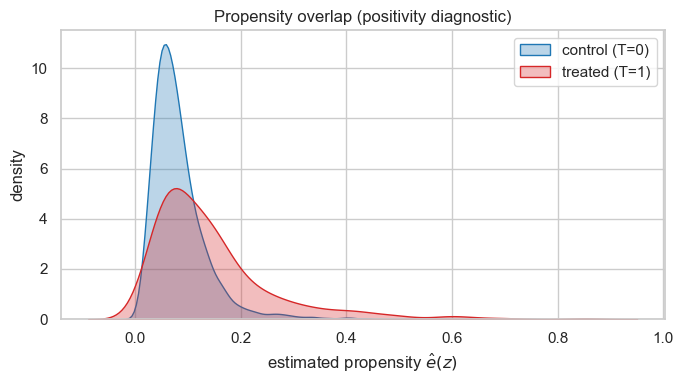


Propensity range — treated: [0.007, 0.855]
Propensity range — control: [0.003, 0.751]


In [7]:
propensity_model = LogisticRegression(max_iter=2000, C=1.0)
propensity_model.fit(Z, T)
e_hat = propensity_model.predict_proba(Z)[:, 1]
sub.obs['propensity'] = e_hat

fig, ax = plt.subplots(figsize=(7, 4))
for t, label, color in [(0, 'control (T=0)', 'tab:blue'), (1, 'treated (T=1)', 'tab:red')]:
    sns.kdeplot(e_hat[T == t], ax=ax, label=label, color=color, fill=True, alpha=0.3)
ax.set_xlabel('estimated propensity $\\hat e(z)$')
ax.set_ylabel('density')
ax.set_title('Propensity overlap (positivity diagnostic)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nPropensity range — treated: [{e_hat[T == 1].min():.3f}, {e_hat[T == 1].max():.3f}]')
print(f'Propensity range — control: [{e_hat[T == 0].min():.3f}, {e_hat[T == 0].max():.3f}]')


## 7. Estimator (1): the naive mean difference

$$\hat\tau_{\text{naive}} = \bar Y_{T = 1} - \bar Y_{T = 0}$$

This is what you get if you ignore cell-state heterogeneity.  We pair it with a percentile bootstrap CI.


In [8]:
def naive_ate(Y: np.ndarray, T: np.ndarray) -> float:
    if (T == 1).sum() == 0 or (T == 0).sum() == 0:
        return np.nan
    return float(Y[T == 1].mean() - Y[T == 0].mean())


def stratified_bootstrap_indices(T: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """Bootstrap treated and control cells separately so each replicate has both groups."""
    treated_idx = np.where(T == 1)[0]
    control_idx = np.where(T == 0)[0]
    if len(treated_idx) == 0 or len(control_idx) == 0:
        raise ValueError(
            f'Cannot bootstrap: need both groups, got {len(treated_idx)} treated and {len(control_idx)} control cells.'
        )
    boot_treated = rng.choice(treated_idx, size=len(treated_idx), replace=True)
    boot_control = rng.choice(control_idx, size=len(control_idx), replace=True)
    return np.concatenate([boot_treated, boot_control])


def bootstrap_ci(estimator_fn, Y: np.ndarray, T: np.ndarray, *extra_arrays,
                 n_boot: int = 200, seed: int = 0, alpha: float = 0.05):
    rng = np.random.default_rng(seed)
    samples = np.empty(n_boot)
    for b in range(n_boot):
        idx = stratified_bootstrap_indices(T, rng)
        boot_args = [Y[idx], T[idx]] + [arr[idx] for arr in extra_arrays]
        samples[b] = estimator_fn(*boot_args)
    samples = samples[~np.isnan(samples)]
    if len(samples) == 0:
        raise ValueError('All bootstrap estimates are NaN. Check treated/control counts and matching inputs.')
    point = estimator_fn(Y, T, *extra_arrays)
    lo, hi = np.quantile(samples, [alpha / 2, 1 - alpha / 2])
    return point, lo, hi, samples


tau_naive, lo, hi, naive_boot = bootstrap_ci(naive_ate, Yv, T, n_boot=CFG.n_bootstrap, seed=CFG.seed)
print(f'Naive ATE     = {tau_naive:+.3f}   95% CI = [{lo:+.3f}, {hi:+.3f}]')


Naive ATE     = +0.570   95% CI = [+0.477, +0.658]


## 8. Estimator (2): $k$-NN matching on $Z$

For every treated cell $i$ we find its $k$ nearest control neighbours $\mathcal{N}(i)$ in $Z$-space, impute the counterfactual

$$\hat Y_i(0) = \frac{1}{k} \sum_{j \in \mathcal{N}(i)} Y_j,$$

and average the individual treatment effects:

$$\hat\tau = \frac{1}{n_T}\sum_{i : T_i = 1}\bigl(Y_i - \hat Y_i(0)\bigr).$$

Under conditional ignorability + overlap (proposal § 2.6) this estimates the **ATT** (average effect on the treated); for our setup ATT $\approx$ ATE.


In [ ]:
def matching_ate(
    Y: np.ndarray, T: np.ndarray, Z: np.ndarray, k: int = 10,
    return_match_idx: bool = False,
):
    """k-NN matching estimator.

    For each treated cell we find the k nearest control cells in Z-space
    and use their average Y as the counterfactual estimate Y_i(0).
    """
    Z_ctrl = Z[T == 0]
    Y_ctrl = Y[T == 0]
    Z_trt = Z[T == 1]
    Y_trt = Y[T == 1]
    if len(Z_ctrl) == 0 or len(Z_trt) == 0:
        raise ValueError(
            f'Matching needs both groups, got {len(Z_trt)} treated and {len(Z_ctrl)} control cells. '
            'Check CFG.control_labels and CFG.target_perturbation.'
        )
    k_eff = min(k, len(Z_ctrl))
    nn = NearestNeighbors(n_neighbors=k_eff, algorithm='auto').fit(Z_ctrl)
    _, idx = nn.kneighbors(Z_trt)
    Y0_hat = Y_ctrl[idx].mean(axis=1)
    tau = float((Y_trt - Y0_hat).mean())
    if return_match_idx:
        return tau, idx
    return tau


tau_match, match_idx = matching_ate(Yv, T, Z, k=CFG.k_neighbors, return_match_idx=True)

# Bootstrap CI for matching: resample treated and control cells separately, then re-match.
rng = np.random.default_rng(CFG.seed)
boot_match = np.empty(CFG.n_bootstrap)
for b in range(CFG.n_bootstrap):
    idx_b = stratified_bootstrap_indices(T, rng)
    boot_match[b] = matching_ate(Yv[idx_b], T[idx_b], Z[idx_b], k=CFG.k_neighbors)
boot_match = boot_match[~np.isnan(boot_match)]
if len(boot_match) == 0:
    raise ValueError('All matching bootstrap estimates are NaN. Check treated/control labels.')
lo_m, hi_m = np.quantile(boot_match, [0.025, 0.975])

print(f'Naive ATE     = {tau_naive:+.3f}   95% CI = [{lo:+.3f}, {hi:+.3f}]')
print(f'Matching ATE  = {tau_match:+.3f}   95% CI = [{lo_m:+.3f}, {hi_m:+.3f}]   (k = {CFG.k_neighbors})')


Naive ATE     = +0.570   95% CI = [+0.477, +0.658]
Matching ATE  = +0.379   95% CI = [+0.306, +0.448]   (k = 10)


### 8.1 Estimator (3): propensity score matching

Instead of matching in the full 33-dim $Z$ space (where nearest neighbours can be unreliable — the curse of dimensionality), we match on the **1-D propensity score** $\hat e(z)=P(T=1\mid Z)$.  By the balancing-score result of Rosenbaum & Rubin (1983), matching on $\hat e(z)$ is sufficient to balance all of $Z$ *if* overlap holds.

For each treated cell we take its $k$ nearest control cells in propensity space and average their $Y$ as the counterfactual $\hat Y_i(0)$.  We report two variants:

- **no caliper**: every treated cell is matched (it always finds *some* controls, even if they are far in propensity);
- **with caliper**: a treated cell is kept only if its nearest control lies within `caliper` propensity units.  This refuses to extrapolate, so treated cells with no comparable control are dropped — and the number dropped is itself an overlap diagnostic.

Caliper = 0.0136 propensity units

PSM ATE (no caliper)   = +0.042   95% CI = [+0.007, +0.114]   (matched 741/741 treated)
PSM ATE (caliper=0.014) = +0.040   95% CI = [-0.003, +0.103]   (matched 738/741 treated)

PSM balance on Z (no caliper):
  max |SMD|  before = 0.384   after = 0.055
  mean |SMD| before = 0.087   after = 0.015
  # covariates |SMD|>0.1: before = 11 / 33   after = 0 / 33


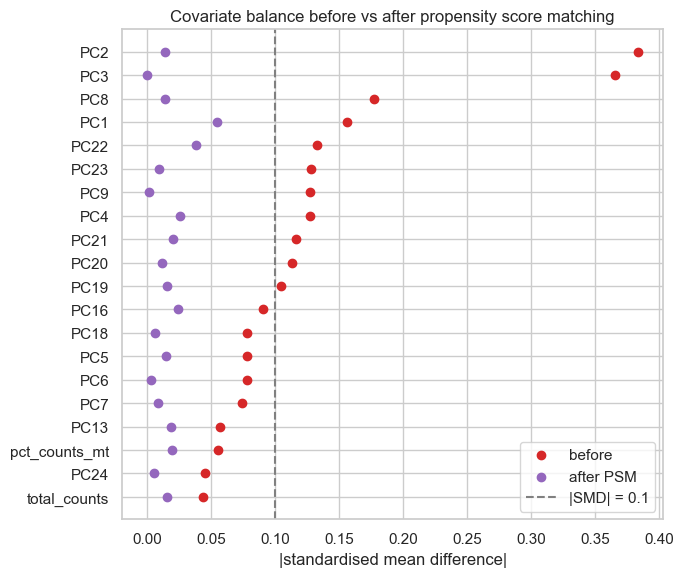

In [10]:
def fit_propensity(Z: np.ndarray, T: np.ndarray) -> np.ndarray:
    m = LogisticRegression(max_iter=2000, C=1.0)
    m.fit(Z, T)
    return m.predict_proba(Z)[:, 1]


def psm_ate(Y, T, e, k=10, caliper=None, return_info=False):
    """Propensity score matching estimator (ATT).

    Match each treated cell to its k nearest control cells in 1-D propensity
    space.  If `caliper` is given (in propensity units), a treated cell is kept
    only when its nearest control is within `caliper`; otherwise it is dropped.
    """
    e = np.asarray(e).reshape(-1, 1)
    e_ctrl = e[T == 0]; Y_ctrl = Y[T == 0]
    e_trt = e[T == 1];  Y_trt = Y[T == 1]
    if len(e_ctrl) == 0 or len(e_trt) == 0:
        return (np.nan, None) if return_info else np.nan
    k_eff = min(k, len(e_ctrl))
    nn = NearestNeighbors(n_neighbors=k_eff).fit(e_ctrl)
    dist, idx = nn.kneighbors(e_trt)
    keep = dist[:, 0] <= caliper if caliper is not None else np.ones(len(e_trt), dtype=bool)
    if keep.sum() == 0:
        return (np.nan, None) if return_info else np.nan
    Y0_hat = Y_ctrl[idx[keep]].mean(axis=1)
    tau = float((Y_trt[keep] - Y0_hat).mean())
    if return_info:
        return tau, {'n_treated_kept': int(keep.sum()),
                     'n_treated_total': int(len(e_trt)),
                     'keep_mask': keep,
                     'matched_control_idx': idx[keep]}
    return tau


def psm_bootstrap_ci(Y, T, Z, k, caliper, n_boot, seed):
    rng = np.random.default_rng(seed)
    samples = []
    for _ in range(n_boot):
        idx = stratified_bootstrap_indices(T, rng)
        e_b = fit_propensity(Z[idx], T[idx])
        tau_b = psm_ate(Y[idx], T[idx], e_b, k=k, caliper=caliper)
        if not np.isnan(tau_b):
            samples.append(tau_b)
    samples = np.array(samples)
    if len(samples) == 0:
        return np.nan, np.nan
    return tuple(np.quantile(samples, [0.025, 0.975]))


# Caliper: a common choice is 0.2 * SD of the propensity score.
caliper = 0.2 * np.std(e_hat)
print(f'Caliper = {caliper:.4f} propensity units')

# Variant A: propensity matching, no caliper
tau_psm, info_psm = psm_ate(Yv, T, e_hat, k=CFG.k_neighbors, caliper=None, return_info=True)
lo_psm, hi_psm = psm_bootstrap_ci(Yv, T, Z, k=CFG.k_neighbors, caliper=None,
                                  n_boot=CFG.n_bootstrap, seed=CFG.seed)

# Variant B: propensity matching, with caliper (refuses to extrapolate)
tau_psm_cal, info_psm_cal = psm_ate(Yv, T, e_hat, k=CFG.k_neighbors, caliper=caliper, return_info=True)
lo_cal, hi_cal = psm_bootstrap_ci(Yv, T, Z, k=CFG.k_neighbors, caliper=caliper,
                                  n_boot=CFG.n_bootstrap, seed=CFG.seed)

print(f'\nPSM ATE (no caliper)   = {tau_psm:+.3f}   95% CI = [{lo_psm:+.3f}, {hi_psm:+.3f}]   '
      f'(matched {info_psm["n_treated_kept"]}/{info_psm["n_treated_total"]} treated)')
if not np.isnan(tau_psm_cal):
    print(f'PSM ATE (caliper={caliper:.3f}) = {tau_psm_cal:+.3f}   95% CI = [{lo_cal:+.3f}, {hi_cal:+.3f}]   '
          f'(matched {info_psm_cal["n_treated_kept"]}/{info_psm_cal["n_treated_total"]} treated)')
else:
    print(f'PSM ATE (caliper={caliper:.3f}) = undefined: no treated cell has a control within the caliper '
          f'(matched 0/{info_psm_cal["n_treated_total"]} treated) -> severe lack of overlap.')

# Balance check for PSM (no caliper): SMD on Z before vs after, using matched controls.
def _smd(z_a, z_b):
    pooled = np.sqrt(0.5 * (z_a.var(axis=0, ddof=1) + z_b.var(axis=0, ddof=1)) + 1e-12)
    return (z_a.mean(axis=0) - z_b.mean(axis=0)) / pooled

ctrl_matched_idx = info_psm['matched_control_idx'].reshape(-1)
Z_trt_kept = Z[T == 1][info_psm['keep_mask']]
smd_before_psm = np.abs(_smd(Z[T == 1], Z[T == 0]))
smd_after_psm = np.abs(_smd(Z_trt_kept, Z[T == 0][ctrl_matched_idx]))
print(f'\nPSM balance on Z (no caliper):')
print(f'  max |SMD|  before = {smd_before_psm.max():.3f}   after = {smd_after_psm.max():.3f}')
print(f'  mean |SMD| before = {smd_before_psm.mean():.3f}   after = {smd_after_psm.mean():.3f}')
print(f'  # covariates |SMD|>0.1: before = {(smd_before_psm > 0.1).sum()} / {len(smd_before_psm)}'
      f'   after = {(smd_after_psm > 0.1).sum()} / {len(smd_after_psm)}')

fig, ax = plt.subplots(figsize=(7, max(4, len(Z_names) * 0.18)))
order = np.argsort(smd_before_psm)[::-1][:20][::-1]
y_pos = np.arange(len(order))
ax.scatter(smd_before_psm[order], y_pos, label='before', color='tab:red')
ax.scatter(smd_after_psm[order], y_pos, label='after PSM', color='tab:purple')
ax.axvline(0.1, color='gray', linestyle='--', label='|SMD| = 0.1')
ax.set_yticks(y_pos)
ax.set_yticklabels([Z_names[i] for i in order])
ax.set_xlabel('|standardised mean difference|')
ax.set_title('Covariate balance before vs after propensity score matching')
ax.legend()
plt.tight_layout()
plt.show()

### 8.2 Restricting to the overlap region (common-support trimming)

The propensity diagnostic (§6.1) showed that treated and control barely overlap.  One standard response is to **trim to the common-support region** and re-estimate there: we keep only cells whose propensity lies in a central band $[\,t,\,1-t\,]$ (Crump et al. 2009 use $t=0.1$).

This changes the estimand — we no longer estimate the effect for *all* HSPA5 cells, but only for the sub-population that has comparable controls (i.e. where positivity plausibly holds).  We then re-run all three estimators on the trimmed sample and check whether balance improves.

Common-support band: [0.1, 0.9]
Kept 2403 / 8287 cells (414/741 treated, 1989/7546 control)

On the trimmed (common-support) sample:
  Naive ATE          = +0.471
  Matching on Z ATE  = +0.485
  PSM ATE            = +0.062

Balance (Z-matching) on trimmed sample:
  mean |SMD| before = 0.069   after = 0.101
  max  |SMD| before = 0.357   after = 0.524
  # covariates |SMD|>0.1: before = 6/33   after = 10/33


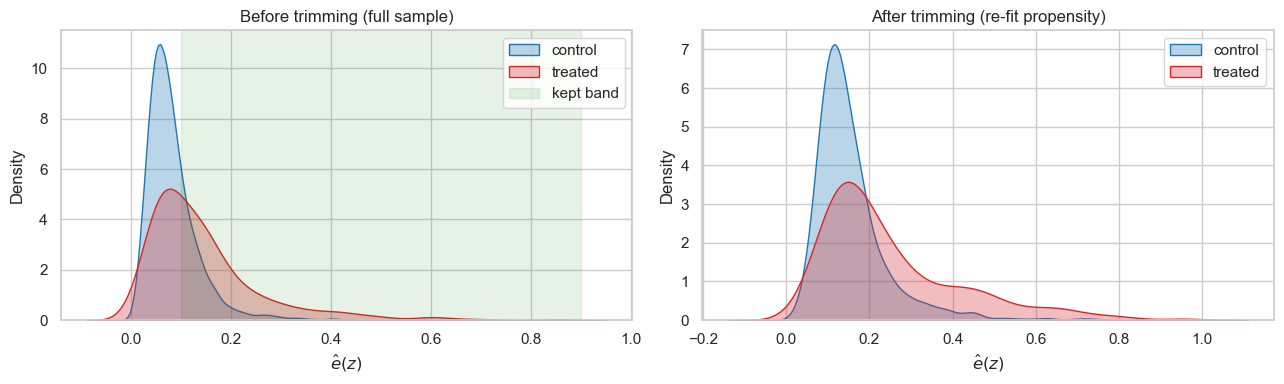

In [11]:
TRIM_T = 0.10  # keep cells with TRIM_T <= e_hat <= 1 - TRIM_T

trim_mask = (e_hat >= TRIM_T) & (e_hat <= 1 - TRIM_T)
T_tr = T[trim_mask]
Y_tr = Yv[trim_mask]
Z_tr = Z[trim_mask]

n_t_tr = int((T_tr == 1).sum())
n_c_tr = int((T_tr == 0).sum())
print(f'Common-support band: [{TRIM_T}, {1 - TRIM_T}]')
print(f'Kept {trim_mask.sum()} / {len(T)} cells '
      f'({n_t_tr}/{int((T==1).sum())} treated, {n_c_tr}/{int((T==0).sum())} control)')

if n_t_tr == 0 or n_c_tr == 0:
    print('\nOne group is empty after trimming -> overlap is so poor that no common-support '
          'region exists at this threshold. Try a larger TRIM_T band or accept that positivity fails.')
else:
    # Re-fit propensity on the trimmed sample (propensity is sample-specific).
    e_tr = fit_propensity(Z_tr, T_tr)

    tau_naive_tr = naive_ate(Y_tr, T_tr)
    tau_match_tr, match_idx_tr = matching_ate(Y_tr, T_tr, Z_tr, k=CFG.k_neighbors, return_match_idx=True)
    tau_psm_tr = psm_ate(Y_tr, T_tr, e_tr, k=CFG.k_neighbors, caliper=None)

    print(f'\nOn the trimmed (common-support) sample:')
    print(f'  Naive ATE          = {tau_naive_tr:+.3f}')
    print(f'  Matching on Z ATE  = {tau_match_tr:+.3f}')
    print(f'  PSM ATE            = {tau_psm_tr:+.3f}')

    # Balance for Z-matching on the trimmed sample.
    Zc_matched_tr = Z_tr[T_tr == 0][match_idx_tr.reshape(-1)]
    smd_before_tr = np.abs(_smd(Z_tr[T_tr == 1], Z_tr[T_tr == 0]))
    smd_after_tr = np.abs(_smd(Z_tr[T_tr == 1], Zc_matched_tr))
    print(f'\nBalance (Z-matching) on trimmed sample:')
    print(f'  mean |SMD| before = {smd_before_tr.mean():.3f}   after = {smd_after_tr.mean():.3f}')
    print(f'  max  |SMD| before = {smd_before_tr.max():.3f}   after = {smd_after_tr.max():.3f}')
    print(f'  # covariates |SMD|>0.1: before = {(smd_before_tr > 0.1).sum()}/{len(smd_before_tr)}'
          f'   after = {(smd_after_tr > 0.1).sum()}/{len(smd_after_tr)}')

    # Propensity overlap before vs after trimming.
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for t, label, color in [(0, 'control', 'tab:blue'), (1, 'treated', 'tab:red')]:
        sns.kdeplot(e_hat[T == t], ax=axes[0], label=label, color=color, fill=True, alpha=0.3)
    axes[0].axvspan(TRIM_T, 1 - TRIM_T, color='green', alpha=0.1, label='kept band')
    axes[0].set_title('Before trimming (full sample)')
    axes[0].set_xlabel(r'$\hat e(z)$'); axes[0].legend()

    for t, label, color in [(0, 'control', 'tab:blue'), (1, 'treated', 'tab:red')]:
        if (T_tr == t).sum() > 1:
            sns.kdeplot(e_tr[T_tr == t], ax=axes[1], label=label, color=color, fill=True, alpha=0.3)
    axes[1].set_title('After trimming (re-fit propensity)')
    axes[1].set_xlabel(r'$\hat e(z)$'); axes[1].legend()
    plt.tight_layout()
    plt.show()

## 9. Diagnostics

### 9.1 Covariate balance (standardised mean difference)

For each covariate we compute the standardised mean difference (SMD)

$$\mathrm{SMD}_j = \frac{\bar Z_j^{\text{trt}} - \bar Z_j^{\text{ctrl}}}{\sqrt{\tfrac12(s_j^{\text{trt},2} + s_j^{\text{ctrl},2})}}$$

both **before matching** (full control sample) and **after matching** (only the matched-in control cells, with multiplicity).  As a rule of thumb $|\mathrm{SMD}| < 0.1$ is considered well-balanced.


covariate  |SMD| before  |SMD| after
      PC2      0.383660     0.357673
      PC3      0.365493     0.292870
      PC8      0.177542     0.163878
      PC1      0.156569     0.089291
     PC22      0.132966     0.101566
     PC23      0.127949     0.089697
      PC9      0.127730     0.006236
      PC4      0.127315     0.145549
     PC21      0.116243     0.080434
     PC20      0.113208     0.101358
     PC19      0.104563     0.051558
     PC16      0.090798     0.089214
     PC18      0.078566     0.053751
      PC5      0.078233     0.053153
      PC6      0.078040     0.079286


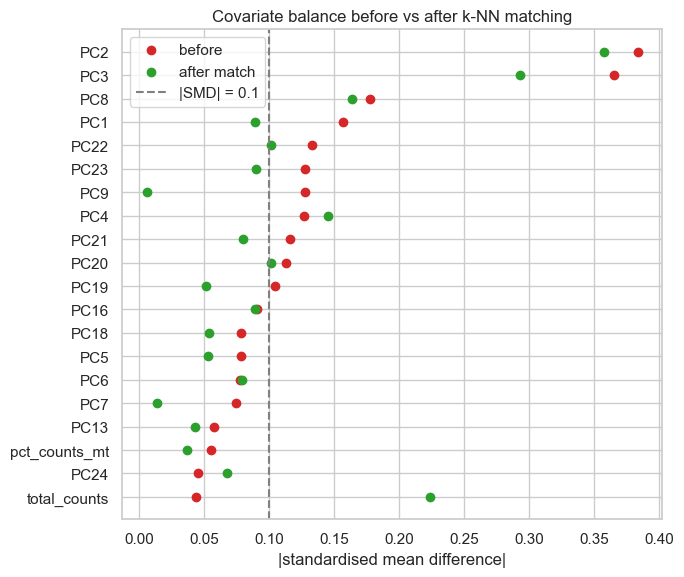

In [12]:
def smd(z_a: np.ndarray, z_b: np.ndarray) -> np.ndarray:
    pooled = np.sqrt(0.5 * (z_a.var(axis=0, ddof=1) + z_b.var(axis=0, ddof=1)) + 1e-12)
    return (z_a.mean(axis=0) - z_b.mean(axis=0)) / pooled


Z_trt = Z[T == 1]
Z_ctrl = Z[T == 0]
Z_ctrl_matched = Z_ctrl[match_idx.reshape(-1)]  # control cells used in matching (with multiplicity)

smd_before = smd(Z_trt, Z_ctrl)
smd_after = smd(Z_trt, Z_ctrl_matched)

balance_df = pd.DataFrame({
    'covariate': Z_names,
    '|SMD| before': np.abs(smd_before),
    '|SMD| after': np.abs(smd_after),
}).sort_values('|SMD| before', ascending=False)

# Show top covariates by pre-match imbalance
print(balance_df.head(15).to_string(index=False))

# Love plot
fig, ax = plt.subplots(figsize=(7, max(4, len(Z_names) * 0.18)))
top = balance_df.head(20).iloc[::-1]
y_pos = np.arange(len(top))
ax.scatter(top['|SMD| before'], y_pos, label='before', color='tab:red')
ax.scatter(top['|SMD| after'], y_pos, label='after match', color='tab:green')
ax.axvline(0.1, color='gray', linestyle='--', label='|SMD| = 0.1')
ax.set_yticks(y_pos)
ax.set_yticklabels(top['covariate'])
ax.set_xlabel('|standardised mean difference|')
ax.set_title('Covariate balance before vs after k-NN matching')
ax.legend()
plt.tight_layout()
plt.show()


### 9.2 Overlap in cell-state space (UMAP)

Quick visual sanity check: are the treated and control cells living in the same region of state space?  We compute a 2-D UMAP on $Z$ if one isn't already in the AnnData.


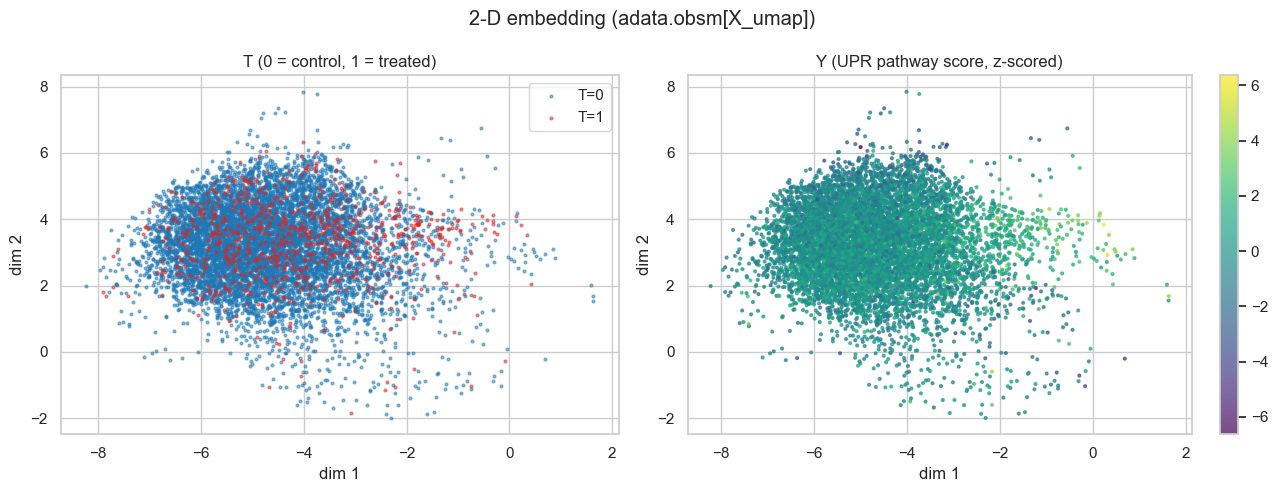

In [13]:
if 'X_umap' in sub.obsm:
    U = np.asarray(sub.obsm['X_umap'])
    umap_source = 'adata.obsm[X_umap]'
else:
    try:
        import umap  # type: ignore
        U = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=CFG.seed).fit_transform(Z)
        umap_source = 'umap-learn on Z'
    except ImportError:
        from sklearn.manifold import TSNE
        U = TSNE(n_components=2, perplexity=30, random_state=CFG.seed, init='pca').fit_transform(Z)
        umap_source = 't-SNE on Z (umap-learn not installed)'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax_i, (col, cmap, title) in zip(axes, [
    (T, ['tab:blue', 'tab:red'], 'T (0 = control, 1 = treated)'),
    (Yv, None, 'Y (UPR pathway score, z-scored)'),
]):
    if isinstance(cmap, list):
        for t in [0, 1]:
            m = (T == t)
            ax_i.scatter(U[m, 0], U[m, 1], s=4, alpha=0.5,
                         color=cmap[t], label=f'T={t}')
        ax_i.legend()
    else:
        sc = ax_i.scatter(U[:, 0], U[:, 1], s=4, alpha=0.7, c=col, cmap='viridis')
        plt.colorbar(sc, ax=ax_i, fraction=0.046)
    ax_i.set_title(title)
    ax_i.set_xlabel('dim 1'); ax_i.set_ylabel('dim 2')
fig.suptitle(f'2-D embedding ({umap_source})')
plt.tight_layout()
plt.show()


## 10. Robustness checks

We sweep two knobs that we expect to matter (proposal § 2.5):

1. **Number of neighbours $k$** — small $k$ means low bias but high variance; large $k$ averages over less-similar controls and may bias toward zero (if treated and control distributions differ).
2. **Subsampling** — re-run on random sub-samples to check stability.


Robustness check sample sizes: n_treated=741, n_control=7546


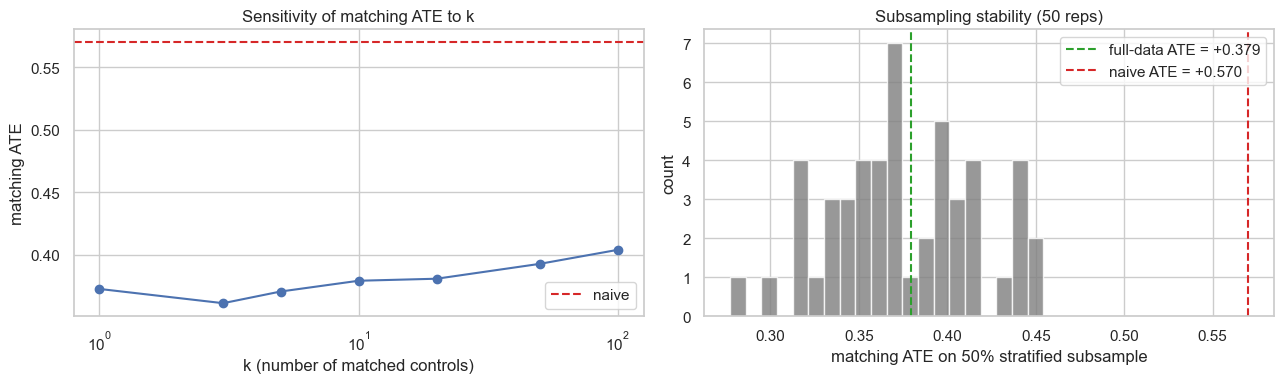

ATE vs k:
  k =   1   tau = +0.373
  k =   3   tau = +0.361
  k =   5   tau = +0.371
  k =  10   tau = +0.379
  k =  20   tau = +0.381
  k =  50   tau = +0.393
  k = 100   tau = +0.404


In [14]:
n_treated = int((T == 1).sum())
n_control = int((T == 0).sum())
print(f'Robustness check sample sizes: n_treated={n_treated}, n_control={n_control}')

if n_treated == 0 or n_control == 0:
    raise ValueError(
        'Robustness checks need both treated and control cells. '
        'If n_control=0, update CFG.control_labels to match the control label in adata.obs[CFG.pert_col].'
    )

ks = [1, 3, 5, 10, 20, 50, 100]
ks = [k for k in ks if k <= n_control]
tau_by_k = [matching_ate(Yv, T, Z, k=k) for k in ks]

# Subsampling: draw treated and control cells separately so every subsample has both groups.
rng = np.random.default_rng(CFG.seed + 1)
treated_idx = np.where(T == 1)[0]
control_idx = np.where(T == 0)[0]
n_sub_treated = max(1, len(treated_idx) // 2)
n_sub_control = max(1, len(control_idx) // 2)
sub_taus = []
for _ in range(50):
    idx_t = rng.choice(treated_idx, size=n_sub_treated, replace=False)
    idx_c = rng.choice(control_idx, size=n_sub_control, replace=False)
    idx_b = np.concatenate([idx_t, idx_c])
    sub_taus.append(matching_ate(Yv[idx_b], T[idx_b], Z[idx_b], k=CFG.k_neighbors))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ks, tau_by_k, marker='o')
axes[0].axhline(tau_naive, color='tab:red', linestyle='--', label='naive')
axes[0].set_xlabel('k (number of matched controls)')
axes[0].set_ylabel('matching ATE')
axes[0].set_title('Sensitivity of matching ATE to k')
axes[0].legend()
if len(ks) > 1 and min(ks) > 0:
    axes[0].set_xscale('log')

axes[1].hist(sub_taus, bins=20, color='tab:gray', alpha=0.8)
axes[1].axvline(tau_match, color='tab:green', linestyle='--', label=f'full-data ATE = {tau_match:+.3f}')
axes[1].axvline(tau_naive, color='tab:red', linestyle='--', label=f'naive ATE = {tau_naive:+.3f}')
axes[1].set_xlabel('matching ATE on 50% stratified subsample')
axes[1].set_ylabel('count')
axes[1].set_title('Subsampling stability (50 reps)')
axes[1].legend()
plt.tight_layout()
plt.show()

print('ATE vs k:')
for k, t in zip(ks, tau_by_k):
    print(f'  k = {k:>3d}   tau = {t:+.3f}')


### 10.1 Multiple guides targeting the same gene

If the dataset records the individual sgRNA used (a `guide`-like column), we can run the matching estimator **separately for each guide** that targets our target gene.  Effects should be roughly consistent across guides — large guide-to-guide variation is a red flag that what we are seeing is off-target / guide-specific rather than a clean knockout effect (proposal §2.5 robustness checks).


In [15]:
CANDIDATE_GUIDE_COLS = ('guide', 'sgRNA', 'sgrna', 'protospacer', 'feature_call', 'gRNA')

def find_guide_column(adata: ad.AnnData) -> Optional[str]:
    for c in CANDIDATE_GUIDE_COLS:
        if c in adata.obs.columns:
            return c
    return None


guide_col = find_guide_column(sub)
if guide_col is None:
    print('No guide-level column found in obs.  Skipping per-guide robustness check.')
    print(f'Looked for: {CANDIDATE_GUIDE_COLS}')
    per_guide_df = None
else:
    print(f'Using guide column: {guide_col!r}')

    # All control cells are reused as the comparison pool for every guide.
    ctrl_mask = T == 0
    Z_ctrl = Z[ctrl_mask]; Y_ctrl = Yv[ctrl_mask]

    rows = []
    guides = sub.obs.loc[T == 1, guide_col].astype(str).value_counts()
    for g, n_g in guides.items():
        if n_g < 10:
            continue
        g_mask = (sub.obs[guide_col].astype(str).values == g) & (T == 1)
        Z_g = Z[g_mask]; Y_g = Yv[g_mask]
        k_eff = min(CFG.k_neighbors, len(Z_ctrl))
        nn = NearestNeighbors(n_neighbors=k_eff).fit(Z_ctrl)
        _, idx = nn.kneighbors(Z_g)
        Y0_hat = Y_ctrl[idx].mean(axis=1)
        tau_g = float((Y_g - Y0_hat).mean())
        tau_naive_g = float(Y_g.mean() - Y_ctrl.mean())
        rows.append({
            'guide': g, 'n_treated': int(n_g),
            'naive': tau_naive_g, 'matching': tau_g,
        })

    per_guide_df = pd.DataFrame(rows).sort_values('guide').reset_index(drop=True)
    print(per_guide_df.to_string(index=False))

    if len(per_guide_df) >= 2:
        fig, ax = plt.subplots(figsize=(7, 4))
        x = np.arange(len(per_guide_df))
        ax.bar(x - 0.18, per_guide_df['naive'], width=0.36, label='naive', color='tab:red', alpha=0.8)
        ax.bar(x + 0.18, per_guide_df['matching'], width=0.36, label='matching', color='tab:green', alpha=0.8)
        ax.axhline(tau_match, color='tab:green', linestyle=':', label=f'pooled matching = {tau_match:+.3f}')
        ax.axhline(tau_naive, color='tab:red', linestyle=':', label=f'pooled naive = {tau_naive:+.3f}')
        ax.axhline(0, color='black', linewidth=0.5)
        ax.set_xticks(x); ax.set_xticklabels(per_guide_df['guide'], rotation=30, ha='right')
        ax.set_ylabel('ATE')
        ax.set_title(f'Per-guide ATE for {target}')
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()


No guide-level column found in obs.  Skipping per-guide robustness check.
Looked for: ('guide', 'sgRNA', 'sgrna', 'protospacer', 'feature_call', 'gRNA')


## 11. Heterogeneous treatment effects $\tau(z)$

We coarsen $Z$ via the leiden clusters already stored on the AnnData (or via k-means on $Z$ as a fallback) and re-run the matching estimator **within each stratum**.  This gives a discrete approximation to

$$\tau(z) = \mathbb{E}[Y(1) - Y(0) \mid Z = z].$$


stratum  n_treated  n_control    naive  matching
      0        350       4306 0.289745  0.190603
      1         25        352 0.010313 -0.087680
     10          1         16      NaN       NaN
     11          0          1      NaN       NaN
     12          0          3      NaN       NaN
      2        182        644 0.695372  0.694102
      3         81       1071 0.174162  0.007311
      4         34        552 0.075139 -0.034854
      5         22        158 0.091184 -0.158030
      6         13        178 0.641677  0.389814
      7         14         88 1.376843  1.280246
      8         16        155 0.306258  0.324749
      9          3         22      NaN       NaN


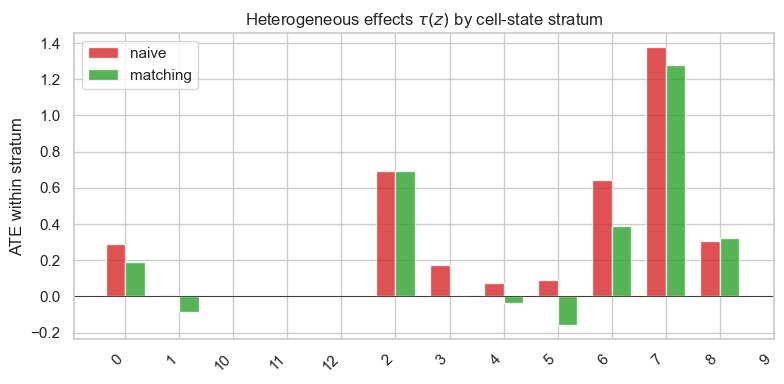

In [16]:
def stratum_labels(adata: ad.AnnData, Z: np.ndarray, cfg: Config) -> pd.Series:
    if 'leiden' in adata.obs.columns:
        return adata.obs['leiden'].astype(str).reset_index(drop=True)
    from sklearn.cluster import KMeans
    km = KMeans(n_clusters=6, random_state=cfg.seed, n_init=10).fit(Z)
    return pd.Series(km.labels_.astype(str), name='kmeans')


strata = stratum_labels(sub, Z, CFG)

rows = []
for s, idx in strata.groupby(strata).groups.items():
    idx = np.array(list(idx))
    Ts = T[idx]; Ys = Yv[idx]; Zs = Z[idx]
    n_t = int(Ts.sum()); n_c = int(len(Ts) - Ts.sum())
    if n_t < 5 or n_c < 5:
        rows.append({'stratum': s, 'n_treated': n_t, 'n_control': n_c, 'naive': np.nan, 'matching': np.nan})
        continue
    k_eff = min(CFG.k_neighbors, n_c)
    rows.append({
        'stratum': s,
        'n_treated': n_t,
        'n_control': n_c,
        'naive': naive_ate(Ys, Ts),
        'matching': matching_ate(Ys, Ts, Zs, k=k_eff),
    })

het_df = pd.DataFrame(rows).sort_values('stratum').reset_index(drop=True)
print(het_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(het_df))
ax.bar(x - 0.18, het_df['naive'], width=0.36, label='naive', color='tab:red', alpha=0.8)
ax.bar(x + 0.18, het_df['matching'], width=0.36, label='matching', color='tab:green', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(het_df['stratum'], rotation=45, ha='right')
ax.set_ylabel('ATE within stratum')
ax.set_title(r'Heterogeneous effects $\tau(z)$ by cell-state stratum')
ax.legend()
plt.tight_layout()
plt.show()


## 12. Summary


Target perturbation: AMIGO3   |   n_treated=741   n_control=7546
Y = mean z-scored expression of 16 UPR genes

             estimator  tau_hat    ci_low  ci_high                                             note
                 naive 0.570015  0.476907 0.658377                 ignores cell-state heterogeneity
  matching on Z (k=10) 0.379175  0.305599 0.448317                    k-NN counterfactual on full Z
PSM, no caliper (k=10) 0.041743  0.007095 0.113711 match on 1-D propensity; 741/741 treated matched
   PSM, caliper (k=10) 0.040100 -0.003228 0.102645           caliper=0.014; 738/741 treated matched


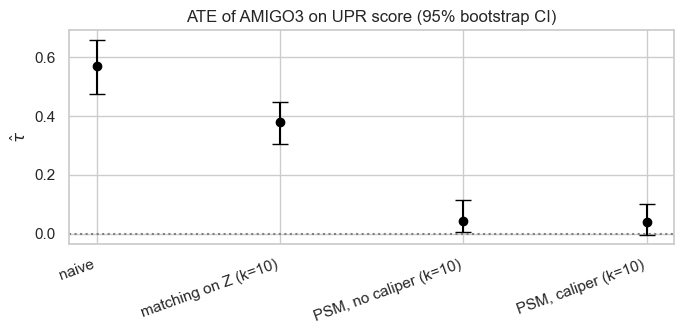

In [17]:
summary_rows = [
    {'estimator': 'naive', 'tau_hat': tau_naive, 'ci_low': lo, 'ci_high': hi,
     'note': 'ignores cell-state heterogeneity'},
    {'estimator': f'matching on Z (k={CFG.k_neighbors})', 'tau_hat': tau_match,
     'ci_low': lo_m, 'ci_high': hi_m,
     'note': 'k-NN counterfactual on full Z'},
    {'estimator': f'PSM, no caliper (k={CFG.k_neighbors})', 'tau_hat': tau_psm,
     'ci_low': lo_psm, 'ci_high': hi_psm,
     'note': f'match on 1-D propensity; {info_psm["n_treated_kept"]}/{info_psm["n_treated_total"]} treated matched'},
]
if not np.isnan(tau_psm_cal):
    summary_rows.append(
        {'estimator': f'PSM, caliper (k={CFG.k_neighbors})', 'tau_hat': tau_psm_cal,
         'ci_low': lo_cal, 'ci_high': hi_cal,
         'note': f'caliper={caliper:.3f}; {info_psm_cal["n_treated_kept"]}/{info_psm_cal["n_treated_total"]} treated matched'})

summary = pd.DataFrame(summary_rows)
print(f'Target perturbation: {target}   |   n_treated={int(T.sum())}   n_control={int((1 - T).sum())}')
print(f'Y = mean z-scored expression of {len(used_genes)} UPR genes\n')
print(summary.to_string(index=False))

# Quick visual:
fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(len(summary))
ax.errorbar(x, summary['tau_hat'],
            yerr=[summary['tau_hat'] - summary['ci_low'], summary['ci_high'] - summary['tau_hat']],
            fmt='o', capsize=6, color='black')
ax.set_xticks(x)
ax.set_xticklabels(summary['estimator'], rotation=20, ha='right')
ax.axhline(0, color='gray', linestyle=':')
ax.set_ylabel(r'$\hat\tau$')
ax.set_title(f'ATE of {target} on UPR score (95% bootstrap CI)')
plt.tight_layout()
plt.show()


## 13. Assumptions and caveats

The numbers above are only as good as the four standard identification assumptions in the proposal (§ 2.6):

- **Consistency** — the `gene` label in `obs` must correspond to an actual perturbation that produced the observed expression.  Mixscape's `mixscape_class_global` lets you check this: cells labelled "NP" (non-perturbed) carry a guide but transcriptionally look like control, and probably should be excluded.
- **Conditional ignorability** — after adjusting for $Z$, treatment is independent of potential outcomes.  $Z$ here is a PCA + QC summary; if there are unmeasured technical confounders (batch, capture efficiency that isn't in `total_counts`, cell-cycle phase, ...) this can fail.  Adding cell-cycle scores or batch IDs to $Z$ is an obvious next step.
- **Overlap (positivity)** — every $z$ in the treated support must also occur in the control support.  The propensity-overlap plot in § 6.1 is the main diagnostic; if treated cells have $\hat e(z) \to 1$ regions where no controls live, the matching estimator is extrapolating and the CI is too narrow.
- **No interference (SUTVA)** — in pooled Perturb-seq this can be violated by paracrine signalling between perturbed cells in the same well, but for a single-perturbation analysis it is usually a mild assumption.

If the **matching ATE differs substantially from the naive ATE**, that is direct evidence that cell-state heterogeneity is acting as a confounder — exactly what the project sets out to demonstrate.  If they are similar, either there is little confounding or our chosen $Z$ does not capture the relevant axes.
